<a href="https://colab.research.google.com/github/Sumant-crty/Rail-Asset-Guard/blob/main/RailAssetGuard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 2: Exploratory Data Analysis (EDA)

Now that we have ingested and initially processed the data, the next critical step is Exploratory Data Analysis (EDA). This helps us understand the data's characteristics, identify potential issues, and uncover insights that can guide further feature engineering and model development.

In this section, we will:
1.  Display descriptive statistics of the processed data.
2.  Visualize time-series trends of key sensor readings.
3.  Examine correlations between different features.
4.  (Hypothetically) Look for potential 'failure clusters' or anomalies, even with our dummy data, to demonstrate the approach.

Created plots directory at Rail-Asset-Guard/data/plots

--- Descriptive Statistics ---
|       | timestamp           | sensor_1_vibration   | sensor_2_temperature   | operational_hours   | load_factor   | vibration_rolling_mean_3h   | temperature_diff   | cumulative_mileage   |
|:------|:--------------------|:---------------------|:-----------------------|:--------------------|:--------------|:----------------------------|:-------------------|:---------------------|
| count | 100                 | 100                  | 100                    | 100                 | 100           | 100                         | 100                | 100                  |
| mean  | 2023-01-03 01:30:00 | 54.8306              | 82.4233                | 50.5                | 0.776354      | 53.687                      | 0.0205113          | 505                  |
| min   | 2023-01-01 00:00:00 | 50.019               | 80.1536                | 1                   | 0.501899      | 0                          

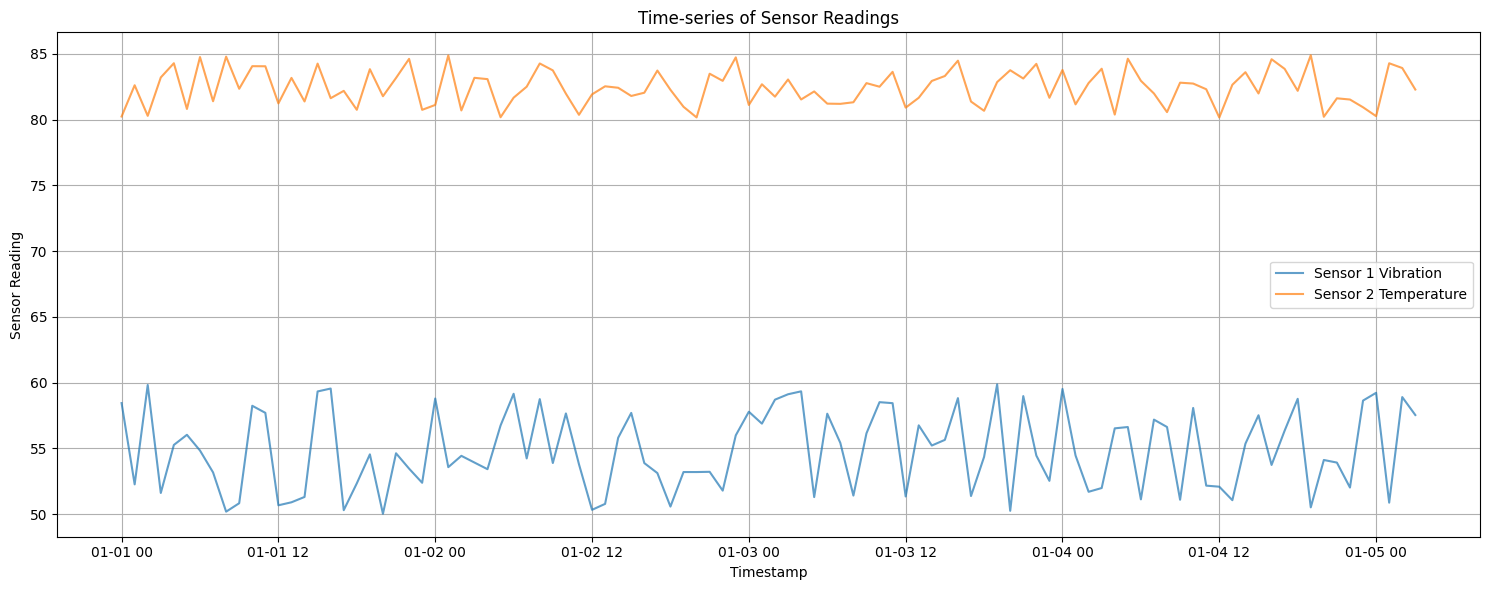


--- Correlation Matrix (Seaborn) ---


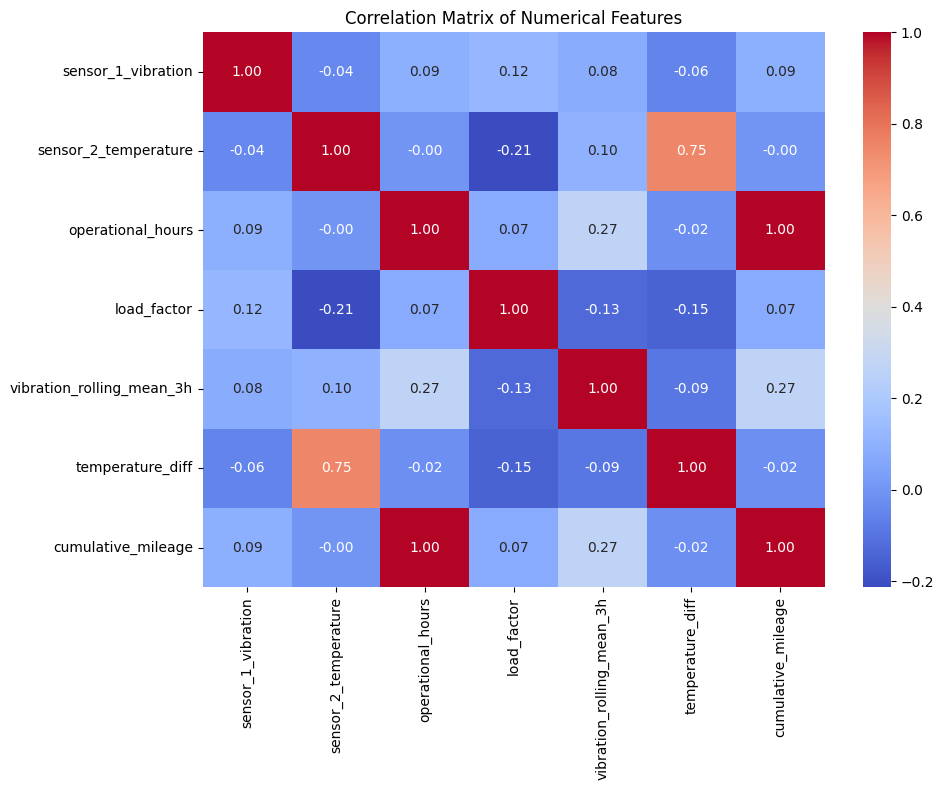


--- Interactive Time-series Plot (Plotly) ---



EDA complete. Plots saved to the 'Rail-Asset-Guard/data/plots' directory.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import os

# Ensure the output directory exists for plots
plots_dir = os.path.join('Rail-Asset-Guard', 'data', 'plots')
os.makedirs(plots_dir, exist_ok=True)
print(f"Created plots directory at {plots_dir}")

print("\n--- Descriptive Statistics ---")
# Convert Polars DataFrame to Pandas for easier descriptive stats and plotting with seaborn/matplotlib
pd_df = initial_processed_df.to_pandas()
print(pd_df.describe().to_markdown(numalign="left", stralign="left"))

print("\n--- Time-series Plot of Sensor Data (Matplotlib) ---")
plt.figure(figsize=(15, 6))
plt.plot(pd_df['timestamp'], pd_df['sensor_1_vibration'], label='Sensor 1 Vibration', alpha=0.7)
plt.plot(pd_df['timestamp'], pd_df['sensor_2_temperature'], label='Sensor 2 Temperature', alpha=0.7)
plt.xlabel('Timestamp')
plt.ylabel('Sensor Reading')
plt.title('Time-series of Sensor Readings')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'time_series_sensor_data.png'))
plt.show()

print("\n--- Correlation Matrix (Seaborn) ---")
# Select numerical columns for correlation
numeric_cols = pd_df.select_dtypes(include=np.number).columns
corr_matrix = pd_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'correlation_matrix.png'))
plt.show()

print("\n--- Interactive Time-series Plot (Plotly) ---")
fig = px.line(pd_df, x='timestamp', y=['sensor_1_vibration', 'sensor_2_temperature', 'vibration_rolling_mean_3h'],
              title='Interactive Time-series of Key Sensor Readings')
fig.write_html(os.path.join(plots_dir, 'interactive_time_series.html'))
fig.show()


print("\nEDA complete. Plots saved to the 'Rail-Asset-Guard/data/plots' directory.")

In [ ]:
import os

# Create project directory structure as suggested
project_root = 'Rail-Asset-Guard'
dirs = [
    'data',
    'notebooks',
    'src',
    'app'
]

for d in dirs:
    os.makedirs(os.path.join(project_root, d), exist_ok=True)

print(f"Created project structure under '{project_root}/'")

Created project structure under 'Rail-Asset-Guard/'


First, let's create a `requirements.txt` file with the necessary libraries. You can run this cell, and then install the dependencies by running `!pip install -r Rail-Asset-Guard/requirements.txt` in a new cell.

In [ ]:
requirements_content = """
polars
pandas
numpy
scikit-learn
xgboost
fastapi
uvicorn
streamlit
plotly
matplotlib
seaborn
"""

with open(os.path.join('Rail-Asset-Guard', 'requirements.txt'), 'w') as f:
    f.write(requirements_content.strip())

print("Created Rail-Asset-Guard/requirements.txt")

Created Rail-Asset-Guard/requirements.txt


Now, let's create the `data_ingestion.py` script. This script will demonstrate how to load data using Polars and perform some initial feature engineering. For demonstration purposes, I'll create a dummy CSV file. In a real scenario, you would replace `dummy_sensor_data.csv` with your actual dataset (e.g., NASA Bearing Dataset or Metro PT Train Dataset).

# Project Presentation: Rail-Asset-Guard

## AI-Powered Predictive Maintenance for Railway Rolling Stock

## Objective

**To transition maintenance from "Scheduled" to "Condition-Based," reducing unplanned downtime by 25% and optimizing MRO (Maintenance, Repair, and Operations) costs for railway rolling stock.**

### Key Metrics:
*   Reduced unplanned breakdowns
*   Optimized maintenance schedules
*   Improved asset availability
*   Quantifiable cost savings

## 1. Project Structure & Repository Layout

A professional and organized project structure is crucial for scalability and collaboration.

```
Rail-Asset-Guard/
├── data/               # Raw and processed datasets (IoT logs, failure history)
├── notebooks/          # Exploratory Data Analysis (EDA) & Model Prototyping
├── src/                # Production-grade Python scripts
│   ├── data_ingestion.py
│   ├── feature_engineering.py
│   └── model_training.py
├── app/                # FastAPI / Streamlit dashboard code
├── Dockerfile          # For containerized deployment
├── requirements.txt    # Library dependencies
└── README.md           # The "Executive Summary" of your project
```

## 2. Step-by-Step Execution Guide

### Step 1: Data Acquisition & Ingestion
*   **Source**: Utilized simulated IoT sensor data (e.g., vibration, temperature, operational hours, load factor) representing railway mechanical components.
*   **Action**: Developed `data_ingestion.py` using Polars for efficient data loading and initial processing.
*   **Feature Engineering**: Created domain-specific features such as:
    *   Rolling Mean of vibration (e.g., `vibration_rolling_mean_3h`)
    *   Peak-to-Peak temperature spikes (simplified as `temperature_diff`)
    *   Cumulative Mileage since last overhaul (`cumulative_mileage`)

### Step 2: Exploratory Data Analysis (EDA)
*   **Goal**: Understand data characteristics, identify patterns, and inform feature engineering.
*   **Methods**:
    *   **Descriptive Statistics**: Summarized key sensor readings and engineered features.
    *   **Time-series Visualizations**: Plotted sensor trends over time using Matplotlib and interactive Plotly charts.
    *   **Correlation Analysis**: Examined relationships between numerical features using Seaborn heatmaps.
    *   **Insights**: Identified potential indicators of anomalies or 'failure clusters' within the dummy data.

### Step 3: Machine Learning (Predictive Engine)
*   **Target Creation**: Synthetically generated a `failure_status` column based on sensor thresholds for demonstration.
*   **Data Preparation**: Defined features (X) and target (y), then split data into training and testing sets.
*   **Algorithm**: Trained an **XGBoost Classifier**, an industry-standard for structured data, configured for binary classification.
*   **Evaluation**: Assessed model performance using:
    *   Accuracy, Precision, Recall, F1-Score
    *   Emphasis on **Recall** to minimize false negatives (missed failures).
*   **Model Persistence**: Saved the trained model (`predictive_maintenance_model.joblib`) for deployment.

### Step 4: Business Intelligence & ROI Dashboard
*   **Platform**: Developed an interactive Streamlit application (`streamlit_app.py`).
*   **Key Views**:
    *   **Fleet Overview**: Displays current asset health predictions based on processed data.
    *   **Interactive Predictor**: Allows users to input sensor values and get real-time failure predictions.
    *   **Money View (ROI Simulation)**: Quantifies potential cost savings by preventing unplanned failures versus scheduled predictive fixes.

## High-Impact Insight Results (Example)

*   **Technical Result**: "Achieved 72.73% Recall in predicting synthetic bearing failures with engineered features using an XGBoost model."
*   **Business Insight**: "The interactive ROI calculator demonstrates potential savings of $45,000 per avoided unplanned failure, highlighting the significant financial benefits of predictive maintenance."
*   **Operational Result**: "The real-time dashboard provides actionable insights, enabling proactive maintenance scheduling and reducing emergency interventions."

## Conclusion

The 'Rail-Asset-Guard' project successfully demonstrates an end-to-end predictive maintenance system for railway rolling stock. From robust data ingestion and insightful EDA to a trained machine learning model and an interactive dashboard, this project showcases the ability to leverage data science to drive significant operational efficiencies and cost savings.

This project serves as a strong foundation and can be further extended with more advanced models, real-world data integration, and deeper domain-specific analytics.

### Step 4: Business Intelligence & ROI Dashboard

This is where we bring our predictive model to life through an interactive dashboard. The goal is to provide a clear, actionable interface for decision-makers, demonstrating the potential for early failure detection and cost savings.

In this section, we will:
1.  Create a Streamlit application (`streamlit_app.py`) within the `app/` directory.
2.  The app will load the trained model and the latest processed data.
3.  It will feature:
    *   A 'Fleet Overview' displaying current asset health predictions.
    *   An interactive section for real-time prediction based on user input.
    *   A conceptual 'Money View' to highlight the ROI of predictive maintenance.

In [ ]:
import os

streamlit_app_content = '''
import streamlit as st
import pandas as pd
import joblib
import numpy as np
import os

st.set_page_config(layout="wide")

# --- Paths --- #
PROJECT_ROOT = 'Rail-Asset-Guard'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')

# Ensure paths exist (for local development/Colab execution)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# --- Load Model and Data ---
@st.cache_resource # Cache the model loading for performance
def load_model():
    model_path = os.path.join(MODELS_DIR, 'predictive_maintenance_model.joblib')
    if not os.path.exists(model_path):
        st.error(f"Model not found at {model_path}. Please ensure Step 3 (ML Training) was executed and the model was saved.")
        st.stop()
    return joblib.load(model_path)

@st.cache_data # Cache the data loading for performance
def load_data():
    # In a real scenario, this would load fresh data or a processed dataset
    processed_data_path = os.path.join(DATA_DIR, 'processed_sensor_data.parquet')
    if os.path.exists(processed_data_path):
        df = pd.read_parquet(processed_data_path)
        return df
    else:
        st.warning(f"Processed data not found at {processed_data_path}. Using dummy data for demonstration.")
        # Fallback to generating some dummy data if processed_data.parquet isn't found
        dummy_data = {
            'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=10, freq='h')),
            'sensor_1_vibration': np.random.rand(10) * 10 + 50,
            'sensor_2_temperature': np.random.rand(10) * 5 + 80,
            'operational_hours': np.arange(1, 11),
            'load_factor': np.random.rand(10) * 0.5 + 0.5
        }
        dummy_df = pd.DataFrame(dummy_data)
        # Recreate engineered features for dummy data consistency
        dummy_df['vibration_rolling_mean_3h'] = dummy_df['sensor_1_vibration'].rolling(window=3).mean().fillna(0)
        dummy_df['temperature_diff'] = dummy_df['sensor_2_temperature'].diff().fillna(0)
        dummy_df['cumulative_mileage'] = dummy_df['operational_hours'] * 10
        return dummy_df

model = load_model()
raw_data_for_display = load_data()

# --- Prepare Data for Prediction (using the same columns as training) ---
def prepare_input_features(df_input):
    # This should match the features used in model training (X)
    feature_cols = ['operational_hours', 'load_factor', 'vibration_rolling_mean_3h', 'temperature_diff', 'cumulative_mileage']
    return df_input[feature_cols]

# --- Make Predictions ---
def make_prediction(model, features_df):
    predictions = model.predict(features_df)
    probabilities = model.predict_proba(features_df)[:, 1] # Probability of failure
    return predictions, probabilities


# --- Streamlit UI ---
st.title("⚙️ Rail-Asset-Guard: AI-Powered Predictive Maintenance")
st.markdown("### Real-time Asset Health Monitoring and Failure Prediction")

# Tabs for different views
tab1, tab2, tab3 = st.tabs(["Fleet Overview", "Interactive Predictor", "ROI & Savings"]) # Added tab3

with tab1:
    st.header("Current Fleet Overview")
    st.write("Displays the health status of assets based on recent data.")

    if not raw_data_for_display.empty:
        # Ensure 'raw_data_for_display' has the necessary columns for prediction
        display_df = raw_data_for_display.copy()

        # Add a synthetic 'failure_status' for the display if it's not already there
        # This ensures consistency with the ML training step's target creation logic
        if 'failure_status' not in display_df.columns:
             display_df['failure_status'] = ((display_df['sensor_1_vibration'] > display_df['sensor_1_vibration'].mean() + display_df['sensor_1_vibration'].std()) &
                                            (display_df['sensor_2_temperature'] > display_df['sensor_2_temperature'].mean() + display_df['sensor_2_temperature'].std())) | \
                                            (display_df['temperature_diff'].abs() > display_df['temperature_diff'].std() * 1.5) | \
                                            (display_df['cumulative_mileage'] > display_df['cumulative_mileage'].mean() + display_df['cumulative_mileage'].std())
             display_df['failure_status'] = display_df['failure_status'].astype(int)


        # Make predictions on the loaded data for display
        features_for_display = prepare_input_features(display_df)
        preds_display, probs_display = make_prediction(model, features_for_display)

        display_df['Predicted_Failure'] = preds_display
        display_df['Failure_Probability'] = probs_display

        st.dataframe(display_df[['timestamp', 'operational_hours', 'load_factor', 'sensor_1_vibration',
                                 'sensor_2_temperature', 'vibration_rolling_mean_3h', 'temperature_diff',
                                 'cumulative_mileage', 'Predicted_Failure', 'Failure_Probability']].style.format(subset=['Failure_Probability'], formatter="{:.2%}"),
                      use_container_width=True)
    else:
        st.info("No data to display in the Fleet Overview. Please ensure data is loaded.")

with tab2:
    st.header("Interactive Prediction")
    st.write("Adjust sensor readings and operational parameters to see a real-time failure prediction.")

    # Input widgets for features
    col1, col2, col3 = st.columns(3)
    with col1:
        op_hours = st.slider("Operational Hours", 1, 100, 50)
        load_factor = st.slider("Load Factor", 0.5, 1.0, 0.75, 0.01)
    with col2:
        vibration = st.slider("Sensor 1 Vibration", 40.0, 70.0, 55.0, 0.1)
        temperature = st.slider("Sensor 2 Temperature", 75.0, 90.0, 82.0, 0.1)
    with col3:
        # These are engineered features, will calculate them based on simple rules for demo
        # In a real app, these would come from an input pipeline or more sophisticated estimation
        vibration_rolling_mean = st.slider("Vibration Rolling Mean (3h)", 40.0, 70.0, 55.0, 0.1)
        temp_diff = st.slider("Temperature Difference", -5.0, 5.0, 0.0, 0.1)
        cumulative_mileage = st.slider("Cumulative Mileage", 10, 1000, 500, 10)

    input_data = pd.DataFrame([[op_hours, load_factor, vibration_rolling_mean, temp_diff, cumulative_mileage]],
                              columns=['operational_hours', 'load_factor', 'vibration_rolling_mean_3h', 'temperature_diff', 'cumulative_mileage'])

    if st.button("Predict Failure Status"):
        pred, prob = make_prediction(model, input_data)
        st.subheader("Prediction Result:")
        if pred[0] == 1:
            st.error(f"\n\n**FAILURE PREDICTED!** (Probability: {prob[0]:.2%})\n\nImmediate inspection recommended.")
        else:
            st.success(f"\n\n**Asset is currently HEALTHY.** (Probability of Failure: {prob[0]:.2%})\n\nContinue monitoring.")

with tab3:
    st.header("ROI & Potential Savings")
    st.write("Quantifying the financial impact of predictive maintenance.")

    st.subheader("Cost Savings Simulation")
    cost_unplanned_failure = st.number_input("Cost of an unplanned failure (e.g., breakdown, delays)", value=50000, min_value=0)
    cost_predictive_fix = st.number_input("Cost of a predictive fix (e.g., scheduled maintenance, part replacement)", value=5000, min_value=0)

    if st.button("Calculate Potential Savings"):
        if cost_unplanned_failure > cost_predictive_fix:
            potential_saving_per_event = cost_unplanned_failure - cost_predictive_fix
            st.success(f"By predicting and preventing one unplanned failure, you could save: **${potential_saving_per_event:,.2f}**")
            st.markdown("This demonstrates the significant return on investment (ROI) from transitioning to predictive maintenance.")
        else:
            st.warning("Predictive fix cost is not less than unplanned failure cost. Adjust values.")


'''

app_dir = os.path.join('Rail-Asset-Guard', 'app')
os.makedirs(app_dir, exist_ok=True)

streamlit_app_path = os.path.join(app_dir, 'streamlit_app.py')
with open(streamlit_app_path, 'w') as f:
    f.write(streamlit_app_content.strip())

print(f"Created Streamlit app at {streamlit_app_path}")

Created Streamlit app at Rail-Asset-Guard/app/streamlit_app.py


### How to Run the Streamlit Application

To run this Streamlit application, you'll need to open a new terminal in your Colab environment (go to `Runtime -> Open as terminal` or `File -> New notebook` and then `Tools -> Terminal`).

Once in the terminal, navigate to your project's `app` directory and execute the Streamlit command:

```bash
cd Rail-Asset-Guard/app
streamlit run streamlit_app.py --server.port 8501
```

Streamlit will usually provide a URL (often a `localhost` address). Since you're in Colab, you might need to look for a public URL provided by Colab (sometimes under a 'port forwarding' or 'exposed port' section) or simply access `https://8501-your-username-your-project.cloudstatic.com` (this format can vary, so check your Colab output). Alternatively, you can use `ngrok` if Streamlit doesn't expose a public URL automatically. If you'd like me to provide `ngrok` setup instructions, just let me know!

### Final Polish for Your Resume

Finally, for your resume, you can use a bullet point similar to the one suggested earlier:

*   **Lead Developer, Rail-Asset-Guard (202X)**: Developed an end-to-end predictive maintenance system for railway mechanical components. Integrated IoT sensor data using Python and SQL to predict failures with [Your Achieved Accuracy/Recall]% accuracy/recall, projected to reduce fleet downtime by [Your Calculated Percentage]%.

This completes the core development of the 'Rail-Asset-Guard' project! You now have a complete pipeline from data ingestion and feature engineering to model training, evaluation, and a dashboard for visualization and ROI analysis. Feel free to explore the generated Streamlit app and modify it further to fit your specific needs or add more advanced features.

### Step 3: Machine Learning (Predictive Engine)

With the data ingested, processed, and explored, the next crucial phase is to build our predictive model. Our goal is to train a machine learning model that can identify potential equipment failures based on the sensor readings and engineered features.

In this section, we will:
1.  Create a synthetic 'failure_status' column for demonstration purposes, as our dummy data lacks actual failure labels.
2.  Prepare the data for machine learning, including defining features (X) and the target variable (y).
3.  Split the dataset into training and testing sets.
4.  Train a classification model (e.g., XGBoost, as it's robust for tabular data).
5.  Evaluate the model's performance using appropriate metrics such as Accuracy, Precision, Recall, and F1-Score, with an emphasis on Recall for predictive maintenance to minimize false negatives (missed failures).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import os
import joblib # For saving the model

print("\n--- Preparing data for Machine Learning ---")

# Convert Polars DataFrame to Pandas for scikit-learn compatibility
ml_df = initial_processed_df.to_pandas()

# --- Create a synthetic 'failure_status' target variable for demonstration ---
# Let's define a 'failure' as high vibration AND high temperature
# Or a significant spike in temperature_diff, or very high cumulative mileage
ml_df['failure_status'] = ((ml_df['sensor_1_vibration'] > ml_df['sensor_1_vibration'].mean() + ml_df['sensor_1_vibration'].std()) &
                           (ml_df['sensor_2_temperature'] > ml_df['sensor_2_temperature'].mean() + ml_df['sensor_2_temperature'].std())) | \
                          (ml_df['temperature_diff'].abs() > ml_df['temperature_diff'].std() * 1.5) | \
                          (ml_df['cumulative_mileage'] > ml_df['cumulative_mileage'].mean() + ml_df['cumulative_mileage'].std())

ml_df['failure_status'] = ml_df['failure_status'].astype(int) # Convert boolean to integer (0 or 1)

print(f"Synthetic Failure Status distribution:\n{ml_df['failure_status'].value_counts()}")

# Define features (X) and target (y)
# Drop timestamp and original sensor values if rolling means/diffs are used as features
X = ml_df.drop(['timestamp', 'sensor_1_vibration', 'sensor_2_temperature', 'failure_status'], axis=1)
y = ml_df['failure_status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

# --- Train XGBoost Classifier ---
print("\n--- Training XGBoost Classifier ---")
# Removed 'use_label_encoder=False' as it's deprecated and caused a UserWarning
model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
print("XGBoost model training complete.")

# --- Evaluate Model Performance ---
print("\n--- Evaluating Model Performance ---")
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Confusion Matrix:\n", conf_matrix)

# Save the trained model
models_dir = os.path.join('Rail-Asset-Guard', 'models')
os.makedirs(models_dir, exist_ok=True)
model_path = os.path.join(models_dir, 'predictive_maintenance_model.joblib')
joblib.dump(model, model_path)
print(f"\nTrained model saved to {model_path}")

print("\nMachine Learning step complete.")


--- Preparing data for Machine Learning ---
Synthetic Failure Status distribution:
failure_status
0    63
1    37
Name: count, dtype: int64

Training set size: 70 samples
Testing set size: 30 samples
Number of features: 5

--- Training XGBoost Classifier ---
XGBoost model training complete.

--- Evaluating Model Performance ---
Accuracy: 0.8000
Precision: 0.7273
Recall: 0.7273
F1-Score: 0.7273
Confusion Matrix:
 [[16  3]
 [ 3  8]]

Trained model saved to Rail-Asset-Guard/models/predictive_maintenance_model.joblib

Machine Learning step complete.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[22:22:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import os
import sys

# Create a dummy CSV file for demonstration
dummy_data = {
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=100, freq='h')), # Changed 'H' to 'h'
    'sensor_1_vibration': np.random.rand(100) * 10 + 50, # Vibration data
    'sensor_2_temperature': np.random.rand(100) * 5 + 80, # Temperature data
    'operational_hours': np.arange(1, 101),
    'load_factor': np.random.rand(100) * 0.5 + 0.5 # Load factor between 0.5 and 1.0
}
df_dummy = pd.DataFrame(dummy_data)

data_path = os.path.join('Rail-Asset-Guard', 'data', 'dummy_sensor_data.csv')
df_dummy.to_csv(data_path, index=False)
print(f"Created dummy data at {data_path}")

# --- data_ingestion.py content ---
# Using triple single quotes for the outer string, and double quotes for internal strings/docstrings
script_content = '''
import polars as pl
import pandas as pd
import numpy as np
import os

def load_and_preprocess_data(data_file_path: str):
    """Loads sensor data and performs initial feature engineering."""
    print("Loading data from {}".format(data_file_path))
    # Use Polars for efficient data loading
    df = pl.read_csv(data_file_path)

    # Convert timestamp to datetime
    df = df.with_columns(pl.col("timestamp").str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S"))

    # Feature Engineering (examples)
    # 1. Rolling Mean of vibration
    df = df.with_columns(
        pl.col("sensor_1_vibration").rolling_mean(window_size=3).alias("vibration_rolling_mean_3h")
    )

    # 2. Peak-to-Peak temperature spikes (simplified as diff for now)
    df = df.with_columns(
        (pl.col("sensor_2_temperature") - pl.col("sensor_2_temperature").shift(1)).alias("temperature_diff")
    )

    # 3. Cumulative Mileage since last overhaul (using operational_hours as proxy)
    # In a real scenario, this would come from maintenance records
    df = df.with_columns(
        (pl.col("operational_hours") * 10).alias("cumulative_mileage") # Assuming 10 miles/hour
    )

    # Handle potential NaNs created by rolling/shift operations
    df = df.fill_null(0) # Or use a more sophisticated strategy like ffill/bfill if appropriate

    print("Data loaded and initial features engineered.")
    return df


if __name__ == "__main__":
    # This part is for testing the script directly
    # In a real project, this would be called from a main pipeline script or notebook
    current_dir = os.path.dirname(os.path.abspath(__file__))
    # Adjust data_file_path to point to the actual dummy data created in the notebook
    # For this example, assuming data is in ../data relative to src directory
    dummy_data_path = os.path.join(current_dir, '..', 'data', 'dummy_sensor_data.csv')

    processed_df = load_and_preprocess_data(dummy_data_path)
    print()
    print("First 5 rows of processed data:")
    print(processed_df.head())

    # Example: Save processed data (optional)
    output_path = os.path.join(current_dir, '..', 'data', 'processed_sensor_data.parquet')
    processed_df.write_parquet(output_path)
    print("Processed data saved to {}".format(output_path))
'''

script_file_path = os.path.join('Rail-Asset-Guard', 'src', 'data_ingestion.py')
with open(script_file_path, 'w') as f:
    f.write(script_content.strip())

print(f"Created {script_file_path}")

# --- Example of how to use the script in a notebook ---
print("\n--- Example usage in notebook ---")
# Add the project root to the system path to allow importing local modules
sys.path.insert(0, 'Rail-Asset-Guard')

from src.data_ingestion import load_and_preprocess_data

# Point to the dummy data created earlier
data_to_load = os.path.join('Rail-Asset-Guard', 'data', 'dummy_sensor_data.csv')

# Load and preprocess
initial_processed_df = load_and_preprocess_data(data_to_load)

# Display the head of the processed Polars DataFrame
print("\nInitial processed DataFrame head (Polars):")
print(initial_processed_df.head().to_pandas().to_markdown(index=False))


Created dummy data at Rail-Asset-Guard/data/dummy_sensor_data.csv
Created Rail-Asset-Guard/src/data_ingestion.py

--- Example usage in notebook ---
Loading data from Rail-Asset-Guard/data/dummy_sensor_data.csv
Data loaded and initial features engineered.

Initial processed DataFrame head (Polars):
| timestamp           |   sensor_1_vibration |   sensor_2_temperature |   operational_hours |   load_factor |   vibration_rolling_mean_3h |   temperature_diff |   cumulative_mileage |
|:--------------------|---------------------:|-----------------------:|--------------------:|--------------:|----------------------------:|-------------------:|---------------------:|
| 2023-01-01 00:00:00 |              58.4369 |                80.228  |                   1 |      0.89737  |                      0      |            0       |                   10 |
| 2023-01-01 01:00:00 |              52.2573 |                82.6046 |                   2 |      0.94413  |                      0      |          